In [66]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import load_and_process_csv

In [67]:
csv_read = load_and_process_csv("../../data/raw/journal-age.csv")

#print(csv_read.columns)

year_of_establishment = {}
for journal, year in zip(csv_read["journal"],
                         csv_read["Age (publisher and/or journal, approximate number)"]):
    #print(journal, year)

    if not journal is None:
        year_of_establishment[journal.lower().replace(" ", "_")] = year


[info] CSV loaded ← ../../data/raw/journal-age.csv


In [68]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [69]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [70]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats

score_dict = defaultdict(list)

year_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():

        score_dict[journal] = get_journal_score(journal_results)

        if journal in year_of_establishment:
            year = year_of_establishment[journal]
            
            year_list.append(year)
            score_list.append(score_dict[journal])
        else:
            print(journal)
            
# Pearson correlation coefficient
r, p_value = stats.pearsonr(year_list, score_list)
print(f"n {len(year_list)} Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

n 171 Pearson correlation: r = 0.166, p = 3.0 %


In [71]:
df = pd.DataFrame({
    'Impact factor': year_list,
    'Open data score': score_list
})

# Write the DataFrame to a CSV file
#df.to_csv('../../data/processed/policy_vs_year_of_establishment.csv', index=False)

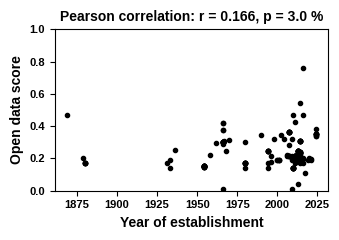

In [72]:
fig = plt.figure(figsize=(3.5, 2.5))

plt.plot(year_list, score_list, ".k")
plt.title(f"Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")
plt.xlabel("Year of establishment")
plt.ylabel("Open data score")
plt.ylim((0.0, 1.0))
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_year_of_establishment.pdf")

In [73]:
#remove outliers and recalculate Pearson correlation coefficient
#impact_factor_list_filtered = []
#score_list_filtered = []
#for impact_factor, score in zip(year_list, score_list):
#    if impact_factor < 75:  # Example threshold to remove outliers
#        impact_factor_list_filtered.append(impact_factor)
#        score_list_filtered.append(score)
#r, p_value = stats.pearsonr(impact_factor_list_filtered, score_list_filtered)
#print(f"After removing outliers: Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")